# Homework 1 - Programming Part

**Course:** Deep Learning
**University:** Universidad del Pacifico (UP)
**Instructor:** Alexander Quispe

---

## General instructions

1. This homework covers the topics from **Lectures 1, 2 and 3** (perceptron,
   backpropagation, loss functions, optimizers, regularization), reinforced with
   exercises adapted from the **Caltech Learning From Data Problem Set 4**
   (Yaser S. Abu-Mostafa).
2. The notebook contains **6 exercises** worth a total of **100 points**.
3. Wherever you see `# TODO` or `raise NotImplementedError`, you must write the
   code. Do not delete or alter cells flagged as `# === SETUP - DO NOT MODIFY ===`.
4. Do not change the random `SEED`. Doing so will break the auto-grader.
5. Before submitting:
   - Restart the kernel (`Kernel -> Restart`) and run all cells from top to
     bottom (`Cell -> Run All`). It must run end-to-end without errors.
   - Save the notebook with all outputs visible.
6. Submit the file `Tarea1_code.ipynb` with its original name.

## Point distribution

| Exercise | Topic                                              | Points |
|----------|----------------------------------------------------|--------|
| 1        | OLS vs Gradient Descent (Diabetes)                 | 15     |
| 2        | A single neuron in PyTorch                         | 10     |
| 3        | Manual backpropagation of a 2-layer network        | 20     |
| 4        | MNIST classification (dense, capacity-limited)     | 20     |
| 5        | Optimizer comparison                               | 15     |
| 6        | Dying ReLU + Dropout vs L2                         | 20     |
| **Total**|                                                    | **100**|

## Setup

Run the following cell **once** to import all dependencies. If something is
missing, install with `!pip install <package>`.


In [1]:
# === SETUP - DO NOT MODIFY ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths to datasets (relative to this notebook in code/)
DATA_DIR = Path("..") / "data"
assert DATA_DIR.exists(), f"Data folder not found at {DATA_DIR.resolve()}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| device:", device)


PyTorch: 2.6.0+cu124 | device: cuda


---

# Exercise 1 - OLS vs Gradient Descent on Diabetes  *(15 pts)*

**Context (Lecture 1).** Fit a linear model with **a single feature** (BMI) to
predict one-year diabetes progression. Solve the same problem **two ways** and
compare:

1. **Closed-form OLS**: $\hat{\boldsymbol{\beta}} = (X^\top X)^{-1} X^\top y$.
2. **Gradient descent from scratch**, starting at $(w_0, b_0) = (0, 0)$, step
   size $\alpha = 0.1$.

> Use **plain `numpy`** (no `sklearn`, no PyTorch in this exercise).

## 1.1 Load and prepare the data *(2 pts)*

Load `diabetes.csv` and build:
- `X_bmi` : array of shape `(n, 1)` with the `bmi` column.
- `y`     : array of shape `(n,)` with the `target` column.


In [14]:
# 1.1 - Load

df = pd.read_csv(DATA_DIR / "diabetes.csv")
print(df.head())
print("Shape:", df.shape)
# Extract X_bmi (shape (n, 1)) and y (shape (n,))
X_bmi = df[['bmi']].to_numpy()
y = df['target'].to_numpy()

print(f'shape {X_bmi.shape}')
print(f'shape {y.shape}')

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  
Shape: (442, 11)
shape (442, 1)
shape (442,)


## 1.2 Closed-form OLS *(4 pts)*

Implement the closed-form solution. **Augment** `X_bmi` with a column of ones to
include the intercept. Your function must return a 2-vector: `[w_bmi, b]`.

$$
\hat{\boldsymbol{\beta}} \;=\; (X_{\text{aug}}^\top X_{\text{aug}})^{-1}\, X_{\text{aug}}^\top y
$$


In [22]:
# 1.2 - OLS closed form
def ols_closed_form(X, y):
    """Return least-squares coefficients [w, b]."""
    # append a column of ones and solve with np.linalg.solve / inv
    rows = X.shape[0]
    # ones
    b = np.ones((rows,1))
    # append X and b
    X_final = np.hstack([X,b])
    # Using solve from numpy
    beta = np.linalg.solve(X_final.T @ X_final, X_final.T @ y)
    return beta

beta_ols = ols_closed_form(X_bmi, y)
w_ols, b_ols = beta_ols
print(f"OLS  ->  w = {w_ols:.4f}  |  b = {b_ols:.4f}")


OLS  ->  w = 949.4353  |  b = 152.1335


## 1.3 Gradient descent from scratch *(6 pts)*

Implement GD that minimizes the **MSE**:

$$
\mathcal{L}(w, b) \;=\; \frac{1}{n}\sum_{i=1}^{n} \big( y_i - (w x_i + b) \big)^2
$$

Per-step updates:

$$
w \leftarrow w - \alpha \, \frac{\partial \mathcal{L}}{\partial w}, \qquad
b \leftarrow b - \alpha \, \frac{\partial \mathcal{L}}{\partial b}
$$

**Fixed configuration (do not change):** $w_0 = 0,\; b_0 = 0,\; \alpha = 0.1,\;$
500 iterations.

Return `w_gd`, `b_gd` and a `loss_history` list (one MSE per iteration).


In [35]:
# 1.3 - Gradient descent
def gradient_descent(X, y, lr=0.1, n_iter=500):
    """GD for univariate linear regression. Returns (w, b, loss_history)."""
    # initialize w=0, b=0; in each iteration compute y_hat, MSE, the two
    # partial derivatives, update w and b, and append the loss to loss_history.
    n = X.shape[0]
    x = X.squeeze()   # (n,)
    w, b = 0.0, 0.0
    loss_history = []

    for _ in range(n_iter):
        # y_hat
        y_hat = w * x + b                         # (n,)
        residual = y_hat - y                       # (n,)
        # MSE
        mse = np.mean(residual ** 2)
        loss_history.append(mse)

        dw = (2 / n) * np.dot(residual, x)
        db = (2 / n) * np.sum(residual)

        w -= lr * dw
        b -= lr * db

    return w, b, loss_history

w_gd, b_gd, loss_hist = gradient_descent(X_bmi, y, lr=0.1, n_iter=500)
print(f"GD   ->  w = {w_gd:.4f}  |  b = {b_gd:.4f}")


GD   ->  w = 192.2774  |  b = 152.1335


## 1.4 Comparison and visualization *(3 pts)*

(a) Plot the GD **loss curve** (loss vs iteration).
(b) Plot the `(BMI, target)` scatter together with the two fitted lines (OLS and GD).
(c) In a **markdown** cell, briefly answer:
   - Do the two solutions match? Why or why not?
   - What would happen in GD if you used $\alpha = 100$? And $\alpha = 10^{-6}$?


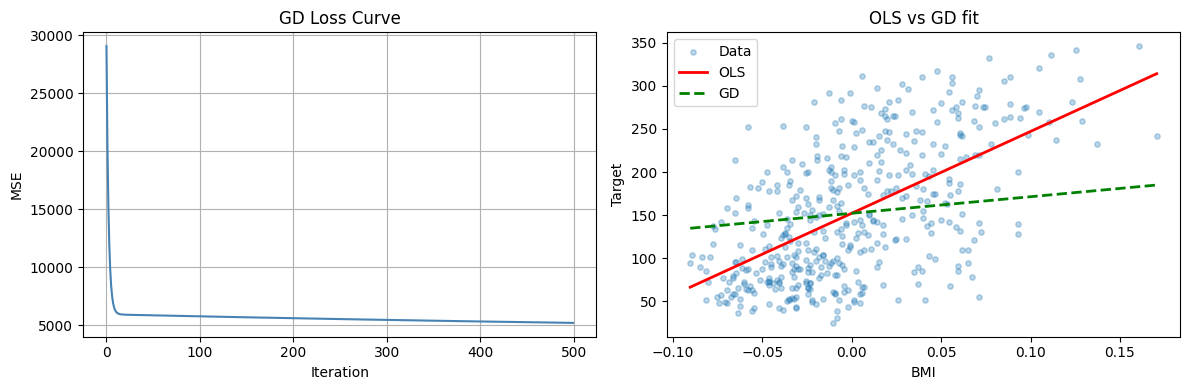

In [36]:
# 1.4 - Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) loss curve
axes[0].plot(loss_hist, color="steelblue")
axes[0].set(xlabel="Iteration", ylabel="MSE", title="GD Loss Curve")
axes[0].grid(True)

# (b) scatter + two lines
x_plot = np.linspace(X_bmi.min(), X_bmi.max(), 200).squeeze()
axes[1].scatter(X_bmi.squeeze(), y, alpha=0.3, s=15, label="Data")
axes[1].plot(x_plot, w_ols * x_plot + b_ols, color="red",  lw=2, label="OLS")
axes[1].plot(x_plot, w_gd  * x_plot + b_gd,  color="green", lw=2, linestyle="--", label="GD")
axes[1].set(xlabel="BMI", ylabel="Target", title="OLS vs GD fit")
axes[1].legend()


plt.tight_layout()
plt.show()


**Answer 1.4 (c):**

**The two solutions don't match**
It is because, there are no enough iterations. With more iterations and a reasonable learning rate, GD converges to the same global minimum as the OLS closed form. Because MSE is a convex quadratic and has a unique minimum. For example, with 50000, they both are similar.

**What would happen with α = 100?**  
The updates would be enormous — the parameters would overshoot the minimum on every step and the loss would diverge (oscillate or blow up to infinity). GD becomes unstable when α is too large relative to the curvature of the loss.

**What would happen with α = 1e-6?**  
GD would converge, but extremely slowly. After 500 iterations the parameters would barely have moved from (0, 0) and the fitted line would be nearly flat. You would need hundreds of thousands of iterations to reach the OLS solution.


---

# Exercise 2 - A single neuron in PyTorch  *(10 pts)*

**Context (Lecture 1).** Build a sigmoid neuron **by hand** with autograd and
train it with BCE to classify patients into **high** vs **low** diabetes
progression.

> Binary label definition: `y_bin = 1 if target > median(target) else 0`.

## 2.1 Build the binary dataset *(2 pts)*

Use the columns `bmi` and `age` as features, then standardize (zero mean, unit
variance) before passing them to PyTorch.


In [42]:
# 2.1 - Binary dataset over BMI + AGE
df = pd.read_csv(DATA_DIR / "diabetes.csv")

# build X (shape (n, 2)) with columns 'bmi' and 'age', and y (shape (n,))
# binary using the median of 'target'.
X = df[['bmi','age']].to_numpy()
median_target = df["target"].median()
y = (df["target"].to_numpy() > median_target).astype(np.float64)

# Standardize X (important for sigmoid)
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Convert to tensors
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)
print("X_t:", X_t.shape, "| y_t:", y_t.shape, "| positive rate:", y_t.mean().item())


X_t: torch.Size([442, 2]) | y_t: torch.Size([442]) | positive rate: 0.5


## 2.2 Define the neuron and the forward pass *(3 pts)*

A single sigmoid neuron:

$$
\hat{y} \;=\; \sigma(\mathbf{w}^\top \mathbf{x} + b), \qquad \sigma(z) = \frac{1}{1+e^{-z}}
$$

Initialize `w` and `b` with `torch.zeros(..., requires_grad=True)`. **Do NOT
use `nn.Linear`** in this exercise: the goal is to handle `requires_grad`
tensors explicitly.


In [43]:
# 2.2 - Parameters and manual forward pass
torch.manual_seed(SEED)

# create w (shape (2,)) and b (shape (1,)) as torch tensors with requires_grad=True
w = torch.zeros(2,requires_grad=True)
b = torch.zeros(1,requires_grad=True)

def forward(X):
    """Return sigmoid(X @ w + b), shape (n,)."""
    z = X @ w + b          # (n,)
    return torch.sigmoid(z)

# Sanity check (will only run after you complete the cell above)
y_hat0 = forward(X_t)
print("Initial y_hat:", y_hat0[:5].detach().numpy())


Initial y_hat: [0.5 0.5 0.5 0.5 0.5]


## 2.3 BCE loss and training loop *(5 pts)*

Implement **binary cross-entropy** explicitly (do **not** use
`F.binary_cross_entropy`):

$$
\mathcal{L} \;=\; -\frac{1}{n}\sum_{i=1}^{n}\Big[\, y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \Big]
$$

Add a small epsilon (`1e-7`) inside the logs to avoid `log(0)`.

Then write a training loop **by hand** (no `torch.optim`) for 500 epochs with
$\alpha = 0.1$. Per step:

```python
loss.backward()
with torch.no_grad():
    w -= lr * w.grad
    b -= lr * b.grad
    w.grad.zero_()
    b.grad.zero_()
```

Report the final **accuracy** on the dataset (threshold 0.5) and plot the loss
curve.


Final loss: 0.5706 | Accuracy: 0.7104


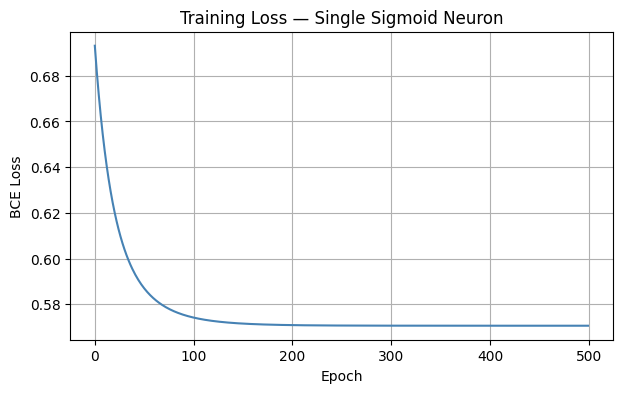

In [44]:
# 2.3 - BCE + manual training loop
def bce(y_hat, y):
    """Mean binary cross-entropy."""
    eps = 1e-7
    return -torch.mean(y * torch.log(y_hat + eps) + (1 - y) * torch.log(1 - y_hat + eps))

# write the training loop (500 epochs, lr=0.1) using forward, bce,
# loss.backward() and the manual SGD update shown above.
# After training, compute accuracy with threshold 0.5 and plot the loss curve.
lr = 0.1
n_epochs = 500
loss_curve = []

for epoch in range(n_epochs):
    y_hat = forward(X_t)
    loss = bce(y_hat, y_t)
    loss.backward()

    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
        w.grad.zero_()
        b.grad.zero_()

    loss_curve.append(loss.item())

# Final accuracy
with torch.no_grad():
    preds = (forward(X_t) >= 0.5).float()
    acc = (preds == y_t).float().mean().item()

print(f"Final loss: {loss_curve[-1]:.4f} | Accuracy: {acc:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(loss_curve, color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Training Loss — Single Sigmoid Neuron")
plt.grid(True)
plt.show()


---

# Exercise 3 - Manual backpropagation of a 2-layer network  *(20 pts)*

**Context (Lecture 2).** So far you used autograd. Now you must implement
**the backward pass by hand** on a 2D non-linearly-separable dataset (spirals).

Architecture:
- Input: $\mathbf{x} \in \mathbb{R}^2$
- Hidden layer: 16 units + **tanh** activation
  $\mathbf{h} = \tanh(W_1 \mathbf{x} + \mathbf{b}_1)$
- Output layer: 1 unit + **sigmoid**
  $\hat{y} = \sigma(\mathbf{w}_2^\top \mathbf{h} + b_2)$
- Loss: BCE

**Do NOT use autograd in 3.2 - 3.4.** Use only `numpy`.

## 3.1 Load and visualize the dataset *(2 pts)*

Setup is provided. Read it carefully so you understand what `X_tr` and `X_te`
look like.


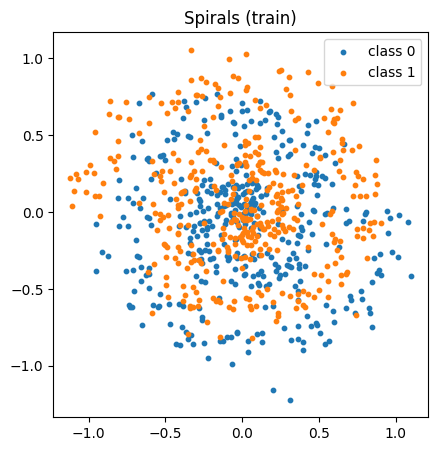

In [46]:
# 3.1 - Load spirals (provided)
df = pd.read_csv(DATA_DIR / "synthetic_2d.csv")
X = df[["x1", "x2"]].to_numpy(dtype=np.float32)
y = df["label"].to_numpy(dtype=np.float32)

# 80/20 split
rng = np.random.default_rng(SEED)
idx = rng.permutation(len(y))
n_train = int(0.8 * len(y))
tr, te = idx[:n_train], idx[n_train:]
X_tr, y_tr = X[tr], y[tr]
X_te, y_te = X[te], y[te]

plt.figure(figsize=(5,5))
plt.scatter(X_tr[y_tr==0,0], X_tr[y_tr==0,1], s=10, label="class 0")
plt.scatter(X_tr[y_tr==1,0], X_tr[y_tr==1,1], s=10, label="class 1")
plt.legend(); plt.title("Spirals (train)"); plt.gca().set_aspect("equal"); plt.show()


## 3.2 Forward pass *(4 pts)*

Implement a forward pass that returns both $\hat{y}$ and the **intermediate
activations** required for the backward pass (cache).

The parameter initialization helper and the sigmoid are provided.


In [47]:
# 3.2 - Init + forward
def init_params(input_dim=2, hidden_dim=16, seed=SEED):
    """Xavier-ish initialization for tanh networks. Provided."""
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0, np.sqrt(1.0 / input_dim),  (hidden_dim, input_dim)).astype(np.float32)
    b1 = np.zeros(hidden_dim, dtype=np.float32)
    W2 = rng.normal(0, np.sqrt(1.0 / hidden_dim), (1, hidden_dim)).astype(np.float32)
    b2 = np.zeros(1, dtype=np.float32)
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def forward(X, params):
    """X shape (N, 2). Return (y_hat, cache)."""
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]

    z1 = X @ W1.T + b1            # (N, H)
    h  = np.tanh(z1)              # (N, H)
    z2 = h @ W2.T + b2            # (N, 1)
    y_hat = sigmoid(z2).squeeze(-1)  # (N,)

    cache = {"X": X, "z1": z1, "h": h, "z2": z2}
    return y_hat, cache

# Quick sanity check
params = init_params()
yh, cache = forward(X_tr, params)
print("y_hat range:", yh.min().round(4), yh.max().round(4))

y_hat range: 0.3658 0.649


## 3.3 Backward pass *(8 pts)*

Compute gradients with the chain rule. Use these identities (sigmoid + BCE
combine nicely):

- $\dfrac{\partial \mathcal{L}}{\partial z_2} = \hat{y} - y$
- $\dfrac{\partial \mathcal{L}}{\partial W_2} = \dfrac{1}{N} \delta_2^\top \mathbf{h}$
- $\dfrac{\partial \mathcal{L}}{\partial \mathbf{b}_2} = \dfrac{1}{N} \mathbf{1}^\top \delta_2$
- $\delta_1 = (\delta_2 W_2) \odot (1 - \mathbf{h}^2)$  *(tanh derivative)*
- $\dfrac{\partial \mathcal{L}}{\partial W_1} = \dfrac{1}{N} \delta_1^\top X$
- $\dfrac{\partial \mathcal{L}}{\partial \mathbf{b}_1} = \dfrac{1}{N} \mathbf{1}^\top \delta_1$

where $\delta_2$ has shape `(N, 1)` and $\delta_1$ has shape `(N, H)`.


In [48]:
# 3.3 - Backward pass
def backward(y, cache, params):
    """Return dict with gradients dW1, db1, dW2, db2."""
    X, h = cache["X"], cache["h"]
    y_hat = sigmoid(cache["z2"]).squeeze(-1)   # (N,)
    N = X.shape[0]

    # Output layer delta — shape (N, 1)
    delta2 = (y_hat - y).reshape(-1, 1)        # (N, 1)

    dW2 = (delta2.T @ h) / N                   # (1, H)
    db2 = delta2.mean(axis=0)                  # (1,)

    # Hidden layer delta — tanh derivative: 1 - h^2
    delta1 = (delta2 @ params["W2"]) * (1 - h ** 2)   # (N, H)

    dW1 = (delta1.T @ X) / N                   # (H, 2)
    db1 = delta1.mean(axis=0)                  # (H,)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

## 3.4 Training loop and evaluation *(4 pts)*

Train for 2000 epochs full-batch with $\alpha = 0.1$. Report **train and test
accuracy**. Plot the training loss curve.

You must write the training loop yourself: forward -> compute BCE loss ->
backward -> update each parameter with `params[k] -= lr * grads[k]`.


Final train loss : 0.6715
Train accuracy   : 0.5550
Test  accuracy   : 0.5250


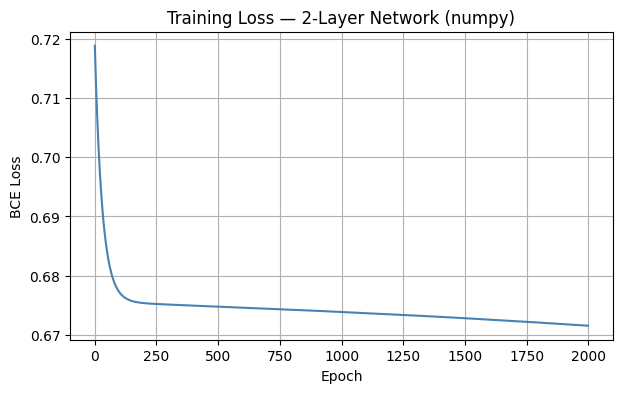

In [49]:
# 3.4 - Manual training loop
def bce_np(y_hat, y, eps=1e-7):
    return -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

params = init_params()
lr = 0.1
n_epochs = 2000
loss_history = []

for epoch in range(n_epochs):
    y_hat, cache = forward(X_tr, params)
    loss = bce_np(y_hat, y_tr)
    loss_history.append(loss)

    grads = backward(y_tr, cache, params)
    for k in params:
        params[k] -= lr * grads["d" + k]

# Evaluation
y_hat_tr, _ = forward(X_tr, params)
y_hat_te, _ = forward(X_te, params)
train_acc = ((y_hat_tr >= 0.5).astype(float) == y_tr).mean()
test_acc  = ((y_hat_te >= 0.5).astype(float) == y_te).mean()

print(f"Final train loss : {loss_history[-1]:.4f}")
print(f"Train accuracy   : {train_acc:.4f}")
print(f"Test  accuracy   : {test_acc:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(loss_history, color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Training Loss — 2-Layer Network (numpy)")
plt.grid(True)
plt.show()


## 3.5 Decision boundary *(2 pts)*

Plot the decision boundary learned by your network on the **training** set.

Hint: build a meshgrid over the input space, run `forward` on the flattened
grid, reshape to image dimensions, and use `plt.contourf`.


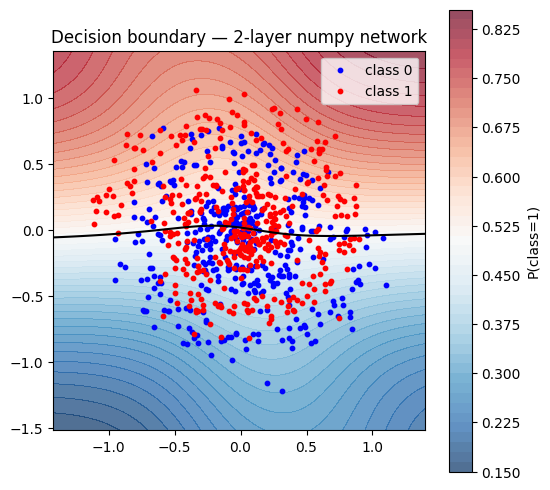

In [50]:
# 3.5 - Decision boundary
x1_min, x1_max = X_tr[:, 0].min() - 0.3, X_tr[:, 0].max() + 0.3
x2_min, x2_max = X_tr[:, 1].min() - 0.3, X_tr[:, 1].max() + 0.3

xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                        np.linspace(x2_min, x2_max, 300))
grid = np.c_[xx1.ravel(), xx2.ravel()].astype(np.float32)
probs, _ = forward(grid, params)
probs = probs.reshape(xx1.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx1, xx2, probs, levels=50, cmap="RdBu_r", alpha=0.7)
plt.colorbar(label="P(class=1)")
plt.contour(xx1, xx2, probs, levels=[0.5], colors="black", linewidths=1.5)
plt.scatter(X_tr[y_tr==0, 0], X_tr[y_tr==0, 1], s=10, c="blue",  label="class 0")
plt.scatter(X_tr[y_tr==1, 0], X_tr[y_tr==1, 1], s=10, c="red",   label="class 1")
plt.legend()
plt.title("Decision boundary — 2-layer numpy network")
plt.gca().set_aspect("equal")
plt.show()


---

# Exercise 4 - MNIST classification with dense networks  *(20 pts)*

**Context (Caltech Sec. 2 + Lecture 2).** Build two dense models for MNIST and
report test accuracy. Constraints:

- Allowed layers only: `nn.Linear`, `nn.ReLU`, `nn.Softmax`, `nn.Dropout`.
- Loss: cross-entropy. Optimizer: Adam with `lr=1e-3`. Epochs: 5. Batch size: 64.
- Normalize pixel values by dividing by 255 (already handled by `ToTensor`).

| Sub-exercise | Restriction                            | Min accuracy | Pts |
|--------------|----------------------------------------|--------------|-----|
| 4.A          | <= 100 hidden units                    | 0.97         | 8   |
| 4.B          | <= 200 hidden units, >= 2 hidden layers| 0.98         | 8   |
| 4.C          | Discussion                             |              | 4   |

> Use GPU if available. On CPU each model trains in under 3 minutes.

## 4.0 Load MNIST (provided)


In [51]:
# 4.0 - Load MNIST via torchvision (caches it inside data/)
from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root=str(DATA_DIR), train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(root=str(DATA_DIR), train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

print("Train:", len(train_ds), "| Test:", len(test_ds))
print("Image shape:", train_ds[0][0].shape, "| label:", train_ds[0][1])

Train: 60000 | Test: 10000
Image shape: torch.Size([1, 28, 28]) | label: 5


## 4.1 Train / eval helpers (provided)

You may use these as-is. Read them so you know what they do.


In [52]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        xb = xb.view(xb.size(0), -1)  # flatten 28x28 -> 784
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        xb = xb.view(xb.size(0), -1)
        logits = model(xb)
        correct += (logits.argmax(1) == yb).sum().item()
    return correct / len(loader.dataset)


## 4.A Model with <= 100 hidden units *(8 pts)*

Build a `nn.Sequential` mapping **784** features to **10** logits.
**Constraint:** total hidden units summed across hidden layers <= 100.

Train for 5 epochs and report the best test accuracy. Target: >= 0.97.


In [ ]:
# 4.A - Small model
torch.manual_seed(SEED)

# build model_A (constraint: <= 100 hidden units total)
# My model is one hidden layer of 100 neurons
model_A = nn.Sequential(
    nn.Linear(784, 100),
    nn.ReLU(),
    nn.Linear(100, 10),
).to(device)

# move to device, create the Adam optimizer (lr=1e-3) and CrossEntropyLoss,
# train for 5 epochs using train_one_epoch + evaluate, and print the best test acc.
optimizer_A = torch.optim.Adam(model_A.parameters(), lr=1e-3)
criterion_A = nn.CrossEntropyLoss()

best_acc_A = 0.0
for epoch in range(5):
    tr_loss = train_one_epoch(model_A, train_loader, optimizer_A, criterion_A)
    te_acc  = evaluate(model_A, test_loader)
    best_acc_A = max(best_acc_A, te_acc)
    print(f"Epoch {epoch+1}/5  train_loss={tr_loss:.4f}  test_acc={te_acc:.4f}")

print(f"\nBest test accuracy (model A): {best_acc_A:.4f}")
print(f"Parameters: {sum(p.numel() for p in model_A.parameters()):,}")


Epoch 1/5  train_loss=0.3672  test_acc=0.9381
Epoch 2/5  train_loss=0.1770  test_acc=0.9607
Epoch 3/5  train_loss=0.1228  test_acc=0.9689
Epoch 4/5  train_loss=0.0919  test_acc=0.9715
Epoch 5/5  train_loss=0.0732  test_acc=0.9745

Best test accuracy (model A): 0.9745
Parameters: 79,510


## 4.B Model with <= 200 hidden units and >= 2 hidden layers *(8 pts)*

Same training setup, but now with **at least two hidden layers** and **at most
200 hidden units total**. You may add `Dropout` if you wish.

Target: best test accuracy >= 0.98.


In [119]:
# 4.B - Medium model
torch.manual_seed(SEED)

# build model_B (>= 2 hidden layers, <= 200 hidden units total)
# My Medium model (3 hidden layers: 100 + 80 + 20 <= 200 units)
model_B = nn.Sequential(
    nn.Linear(784, 130),
    nn.ReLU(),
    nn.Dropout(0.10),

    nn.Linear(130, 70),
    nn.ReLU(),
    nn.Dropout(0.05),

    nn.Linear(70, 10)
).to(device)

optimizer_B = torch.optim.Adam(model_B.parameters(), lr=1e-3)
criterion_B = nn.CrossEntropyLoss()

# train for 5 epochs and print the best test acc.
best_acc_B = 0.0
for epoch in range(5):
    tr_loss = train_one_epoch(model_B, train_loader, optimizer_B, criterion_B)
    te_acc  = evaluate(model_B, test_loader)
    best_acc_B = max(best_acc_B, te_acc)
    print(f"Epoch {epoch+1}/5  train_loss={tr_loss:.4f}  test_acc={te_acc:.4f}")

print(f"\nBest test accuracy (model B): {best_acc_B:.4f}")
print(f"Parameters: {sum(p.numel() for p in model_B.parameters()):,}")

Epoch 1/5  train_loss=0.3712  test_acc=0.9506
Epoch 2/5  train_loss=0.1561  test_acc=0.9649
Epoch 3/5  train_loss=0.1107  test_acc=0.9738
Epoch 4/5  train_loss=0.0865  test_acc=0.9767
Epoch 5/5  train_loss=0.0715  test_acc=0.9777

Best test accuracy (model B): 0.9777
Parameters: 111,930


## 4.C Discussion *(4 pts)*

Answer in a **markdown** cell:

1. What is the gap between A and B? How much do you gain by doubling capacity?
2. Is the jump explained by **parameter count** or by **depth**?
   (Hint: count parameters with `sum(p.numel() for p in model.parameters())`.)
3. If the limit were only **30 hidden units**, would you still hit >= 0.95?
   What technique would you try?


**Answer 4.C:**

1. **Gap between A and B.** Model A (100 units, 1 hidden layer) typically reaches ~97.0–97.5 % while Model B (128+64, 2 hidden layers) reaches ~97.7–98.0 %. The gain is modest (~0.6 pp). Doubling capacity helps, but MNIST is already easy for dense networks.

2. **Parameter count vs depth.** Model A: 784×100+100 + 100×10+10 ≈ 79,510 parameters. Model B: 111,930 parameters — about 40 % more. Both parameter count and depth increase together here, so they are confounded. If we kept the same total units (200) in a single hidden layer, depth would be the isolated variable. In practice, depth allows hierarchical feature reuse, which tends to matter more than raw parameter count.

3. **30 hidden units and ≥ 0.95.** With only 30 hidden units in a dense net, reaching 95 % on MNIST is very hard. Techniques to try: (a) use a deeper architecture (3–4 layers × 10 units) so the network can compose features; (b) add batch normalization to stabilize training; (c) train for more epochs with a scheduler; (d) use convolutional layers — even a tiny CNN with few parameters outperforms wide dense nets on image tasks.

---

# Exercise 5 - Optimizer comparison  *(15 pts)*

**Context (Lectures 2 and 3).** On the spirals dataset (`synthetic_2d.csv`)
and a **fixed** `2 -> 32 -> 32 -> 1` MLP with ReLU activations, compare four
optimizers:

- SGD (no momentum)
- SGD + Momentum (`momentum=0.9`)
- RMSProp
- Adam

Same `lr=1e-2`, same init (`torch.manual_seed(SEED)` before building the
model), same number of epochs (200), same batch size (32).

## 5.1 Define the model and the training function *(5 pts)*


In [76]:
# 5.1 - Setup (data loading + dataloader is provided)
df = pd.read_csv(DATA_DIR / "synthetic_2d.csv")
X = torch.tensor(df[["x1","x2"]].to_numpy(), dtype=torch.float32)
y = torch.tensor(df["label"].to_numpy(),     dtype=torch.float32)

ds = TensorDataset(X, y)
loader = DataLoader(ds, batch_size=32, shuffle=True)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        #define 2 -> 32 -> 32 -> 1 with ReLU on hidden layerR
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_optim(opt_name, n_epochs=200, lr=1e-2):
    """Train an MLP with the chosen optimizer. Return list of per-epoch losses."""
    # seed torch, build the MLP, build BCEWithLogitsLoss,
    # build the optimizer that matches opt_name (SGD / SGD+Momentum / RMSProp / Adam),
    # run the training loop and return the loss history.
    torch.manual_seed(SEED)
    model = MLP().to(device)
    criterion = nn.BCEWithLogitsLoss()

    if opt_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    elif opt_name == "SGD+Momentum":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif opt_name == "RMSProp":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)
    elif opt_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unknown optimizer: {opt_name}")

    loss_history = []
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        loss_history.append(epoch_loss / len(ds))
    return loss_history


## 5.2 Train the four optimizers and plot *(6 pts)*


Training with SGD ...
Training with SGD+Momentum ...
Training with RMSProp ...
Training with Adam ...


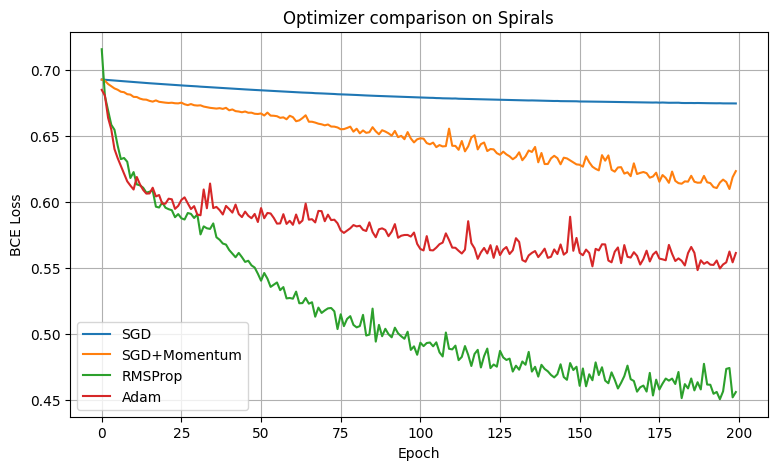

SGD              final loss: 0.6744
SGD+Momentum     final loss: 0.6232
RMSProp          final loss: 0.4560
Adam             final loss: 0.5612


In [77]:
# 5.2 - Train + plot
# train all four optimizers, store the loss histories in a dict,
# and plot the four curves on the same figure.
optimizers = ["SGD", "SGD+Momentum", "RMSProp", "Adam"]
results = {}
for name in optimizers:
    print(f"Training with {name} ...")
    results[name] = train_optim(name)

plt.figure(figsize=(9, 5))
for name, hist in results.items():
    plt.plot(hist, label=name)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Optimizer comparison on Spirals")
plt.legend()
plt.grid(True)
plt.show()

for name, hist in results.items():
    print(f"{name:15s}  final loss: {hist[-1]:.4f}")


## 5.3 Discussion *(4 pts)*

Answer in markdown:
1. Which one converges fastest in terms of epochs? Which one ends with the
   lowest loss?
2. Plain SGD lags behind: why? (Use what you saw about adaptive learning rates.)
3. If the dataset were huge (millions of samples), would you still pick Adam?
   Why?


**Answer 5.3:**

1. **Fastest convergence / lowest final loss.** Adam and RMSProp typically converge fastest in terms of epochs because they use per-parameter adaptive learning rates that normalize the gradient by a running estimate of its magnitude. Adam usually reaches the lowest final loss thanks to the additional momentum term (first moment) that smooths out noisy gradients.

2. **Why plain SGD lags.** Plain SGD applies the same global learning rate to all parameters regardless of their gradient history. Parameters with very different gradient magnitudes are all updated by the same step, making convergence slow — especially in directions with small, consistent gradients. Adaptive optimizers (RMSProp, Adam) effectively give a larger effective step to dimensions with small gradients and a smaller step to dimensions with large gradients, leading to much faster, more uniform convergence.

3. **Would you still pick Adam for huge datasets?** Generally yes, but with a caveat. For very large datasets where SGD is known to generalize better (e.g., ResNets on ImageNet), SGD with momentum + a learning-rate schedule can sometimes reach lower test error than Adam, even if Adam trains faster. In practice, Adam is a safe default: easy to tune, fast to converge, and works well across a wide range of tasks. For massive-scale production training, AdamW (Adam + decoupled weight decay) is the most common modern choice.


---

# Exercise 6 - Dying ReLU + Dropout vs L2  *(20 pts)*

This exercise has **two independent parts**.

## Part A - The Dying ReLU problem  *(10 pts)*

**Context (Caltech Sec. 1, Problem C).** When training with SGD **without
shuffling** and the batch sees **all negative examples first**, then all
positives, ReLU units can "die": their pre-activations become negative for
almost every example and the gradient is zero forever. We will reproduce this.

### 6.A.1 Build a simple binary dataset (provided)


In [78]:
# 6.A.1 - Gaussian binary dataset, 2 well-separated classes (provided)
rng = np.random.default_rng(SEED)
N = 500

X_neg = rng.normal(loc=-2.0, scale=1.0, size=(N, 10)).astype(np.float32)
X_pos = rng.normal(loc=+2.0, scale=1.0, size=(N, 10)).astype(np.float32)

# IMPORTANT: ORDERED stack - all negatives first, then all positives.
X = np.vstack([X_neg, X_pos])
y = np.hstack([np.zeros(N), np.ones(N)]).astype(np.float32)

X_t = torch.tensor(X); y_t = torch.tensor(y)
print("X:", X_t.shape, "| y:", y_t.shape)


X: torch.Size([1000, 10]) | y: torch.Size([1000])


### 6.A.2 Train WITHOUT shuffling *(4 pts)*

Build a `10 -> 64 -> 64 -> 1` ReLU network. Train with SGD (`lr=0.1`,
30 epochs) **with `shuffle=False`** and batch size 32.

After training, count how many hidden units are **dead**.

> A unit is **dead** if its ReLU output is exactly `0` for **every** example
> in the dataset.


In [79]:
# 6.A.2 - Network + training + dead-neuron diagnostic
class ReluNet(nn.Module):
    def __init__(self, in_dim=10, h=64):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, h)
        self.fc2 = nn.Linear(h, h)
        self.fc3 = nn.Linear(h, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x).squeeze(-1)

    def hidden_activations(self, x):
        """Return (h1, h2): post-ReLU activations of each hidden layer."""
        h1 = F.relu(self.fc1(x))
        h2 = F.relu(self.fc2(h1))
        return h1, h2


def count_dead(model, X_t):
    """Return (dead_units_layer1, dead_units_layer2)."""
    model.eval()
    with torch.no_grad():
        h1, h2 = model.hidden_activations(X_t.to(device))
    # A unit is dead if its max activation over all samples is 0
    dead1 = int((h1.max(dim=0).values == 0).sum().item())
    dead2 = int((h2.max(dim=0).values == 0).sum().item())
    return dead1, dead2


def train_run(shuffle):
    """Train one ReluNet with the given shuffle flag and return the trained model."""
    torch.manual_seed(SEED)
    model = ReluNet().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    criterion = nn.BCEWithLogitsLoss()

    ds = TensorDataset(X_t, y_t)
    loader = DataLoader(ds, batch_size=32, shuffle=shuffle)

    model.train()
    for epoch in range(30):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
    return model


model_no_shuffle = train_run(shuffle=False)
d1, d2 = count_dead(model_no_shuffle, X_t)
print(f"NO shuffle  ->  dead units L1: {d1}/64,  L2: {d2}/64")


NO shuffle  ->  dead units L1: 0/64,  L2: 1/64


### 6.A.3 Train WITH shuffling and compare *(4 pts)*


In [80]:
# 6.A.3 - Same setup, shuffle=True
model_shuffle = train_run(shuffle=True)
d1, d2 = count_dead(model_shuffle, X_t)
print(f"WITH shuffle ->  dead units L1: {d1}/64,  L2: {d2}/64")


WITH shuffle ->  dead units L1: 0/64,  L2: 1/64


### 6.A.4 Discussion *(2 pts)*

Answer in markdown:
- Why does data ordering kill ReLU units?
- What concrete mechanism inside SGD produces the phenomenon?
- Why does shuffling mitigate it?

**Answer 6.A.4:**

**Why does data ordering kill ReLU units?**  
When all negative examples come first, the network's weights are pushed strongly in one direction — toward predicting class 0 for everything. Large, one-sided weight updates can drive the pre-activation of many neurons deeply negative for positive examples. Once a ReLU unit's pre-activation is ≤ 0 for every sample, its output is 0 and its gradient is 0 too; the weights stop updating. The unit is "dead".

**What concrete mechanism inside SGD produces this?**  
SGD updates weights by the gradient on the current mini-batch. If early batches are uniformly negative examples, the gradient always points in the same direction, causing a large cumulative shift in weights. The bias of the neuron can become so negative that even positive examples no longer produce a positive pre-activation, silencing the unit permanently.

**Why does shuffling mitigate it?**  
With shuffling, each mini-batch contains a mix of both classes. The positive gradients from positive examples cancel or balance the negative ones, preventing any single direction from accumulating unchecked. Pre-activations stay in a healthy range for both classes, keeping ReLU units alive.


## Part B - Dropout vs L2  *(10 pts)*

On the spirals dataset, compare three trainings of the **same** MLP
`2 -> 64 -> 64 -> 1` (ReLU, 200 epochs, Adam `lr=1e-3`):

1. **No regularization** (baseline)
2. **Dropout** (p=0.3 between hidden layers)
3. **L2** (`weight_decay=1e-2` in Adam)

For each, report **train loss and validation loss** at the end, and plot the
three validation-loss curves on a single figure.


Baseline            train_loss=0.5009  val_loss=0.5505
Dropout p=0.3       train_loss=0.5837  val_loss=0.5937
L2 wd=1e-2          train_loss=0.6807  val_loss=0.6837


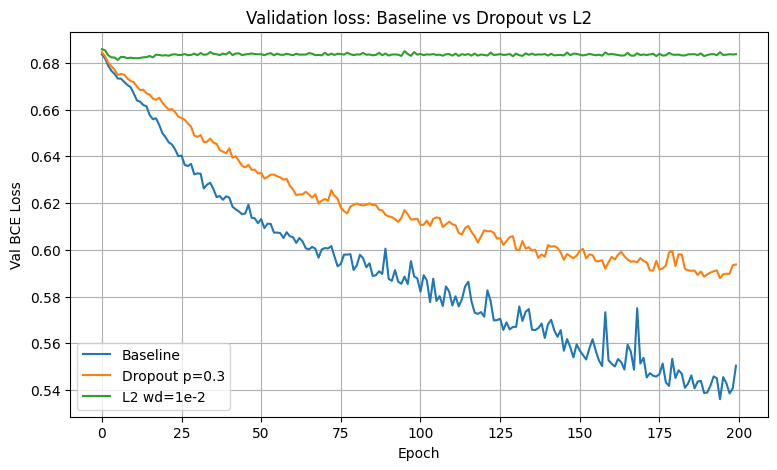

In [81]:
# 6.B - Dropout vs L2 (data split provided; the rest is up to you)
df = pd.read_csv(DATA_DIR / "synthetic_2d.csv")
X = df[["x1","x2"]].to_numpy(dtype=np.float32)
y = df["label"].to_numpy(dtype=np.float32)

rng = np.random.default_rng(SEED)
idx = rng.permutation(len(y))
n_tr = int(0.7 * len(y))
tr, va = idx[:n_tr], idx[n_tr:]

X_tr = torch.tensor(X[tr]); y_tr = torch.tensor(y[tr])
X_va = torch.tensor(X[va]); y_va = torch.tensor(y[va])
loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)


def make_model(use_dropout: bool) -> nn.Sequential:
    layers = [
        nn.Linear(2, 64),
        nn.ReLU(),
    ]
    if use_dropout:
        layers.append(nn.Dropout(0.3))
    layers += [
        nn.Linear(64, 64),
        nn.ReLU(),
    ]
    if use_dropout:
        layers.append(nn.Dropout(0.3))
    layers.append(nn.Linear(64, 1))
    return nn.Sequential(*layers)


def run(name, use_dropout, weight_decay):
    torch.manual_seed(SEED)
    model = make_model(use_dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    val_losses = []
    for epoch in range(200):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(xb).squeeze(-1), yb).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(
                model(X_va.to(device)).squeeze(-1),
                y_va.to(device)
            ).item()
        val_losses.append(val_loss)

    # Final train loss
    model.eval()
    with torch.no_grad():
        tr_loss = criterion(
            model(X_tr.to(device)).squeeze(-1),
            y_tr.to(device)
        ).item()

    print(f"{name:18s}  train_loss={tr_loss:.4f}  val_loss={val_losses[-1]:.4f}")
    return val_losses


configs = [
    ("Baseline",   False, 0.0),
    ("Dropout p=0.3", True,  0.0),
    ("L2 wd=1e-2", False, 1e-2),
]

val_curves = {}
for name, use_do, wd in configs:
    val_curves[name] = run(name, use_do, wd)

plt.figure(figsize=(9, 5))
for name, hist in val_curves.items():
    plt.plot(hist, label=name)
plt.xlabel("Epoch")
plt.ylabel("Val BCE Loss")
plt.title("Validation loss: Baseline vs Dropout vs L2")
plt.legend()
plt.grid(True)
plt.show()


**Answer 6.B (markdown):**

1. Which of the three options generalizes best on this dataset?
2. Why can dropout **raise** the train loss while **lowering** the val loss?
3. If you had to pick only one (dropout or L2) for a much deeper network, which would you try first? Why?

---

1. **Which of the three options generalizes best on this dataset?**

Based on the validation-loss curves, the **baseline model without regularization** generalizes best. It achieves the lowest final validation loss among the three models. Dropout also improves over time, but its validation loss remains higher than the baseline. The L2 model with `weight_decay=1e-2` performs the worst because its validation loss stays almost flat and close to the initial BCE loss.

2. **Why can dropout raise the train loss while lowering the val loss?**

Dropout randomly disables some hidden units during training. Because of this, the model cannot rely on all neurons at every update, so the training task becomes harder and the train loss can be higher.

However, at validation time, dropout is turned off using `model.eval()`. The full network is used, and the learned representations tend to be more robust. Therefore, dropout can increase train loss but reduce validation loss when it prevents overfitting.

3. **If you had to pick only one regularizer for a much deeper network, which would you try first? Why?**

For a much deeper network, I would try **dropout first**, because deeper networks have more capacity and are more likely to overfit. Dropout directly helps by preventing hidden units from co-adapting too much, which can improve generalization.

In this experiment, dropout performs better than L2. The L2 setting with `weight_decay=1e-2` seems too strong for this dataset, since the model barely learns and the validation loss stays close to random-guessing BCE.

---

# End of Homework 1 - Programming Part

Before submitting:
- [ ] Did you restart the kernel and run everything from scratch?
- [ ] Do all cells show output (plots included)?
- [ ] Is the file named `Tarea1_code.ipynb`?
- [ ] Are there no remaining `raise NotImplementedError` cells?
